# EDA — Matching Escolar Bogota

**Pregunta central:** La calidad academica (`q_j`) explica la demanda por colegios (`sobre_demanda_j`),
o existe varianza sistematica no explicada que podria atribuirse a senales visuales?

**Dataset:** `data/primary/colegios_features.geojson` — 306 colegios oficiales de Bogota.

**Secciones:**
1. Carga y descripcion general
2. Distribuciones univariadas
3. Geografia: patrones espaciales de calidad y demanda
4. Relacion `q_j` vs `sobre_demanda_j` — el corazon del paper
5. Controles socioeconomicos y correlaciones

In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

warnings.filterwarnings('ignore')

# Rutas del proyecto
BASE      = Path('..').resolve()
PRIMARY   = BASE / 'data' / 'primary'
FIGURES   = BASE / 'reports' / 'figures' / 'eda'
FIGURES.mkdir(parents=True, exist_ok=True)

# Estilo global de graficas
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

ACCENT = '#2c7bb6'   # azul principal
RED    = '#d7191c'   # rojo para outliers
GREEN  = '#1a9641'   # verde para referencia

print('Rutas configuradas.')

Rutas configuradas.


---
## 1. Carga y descripcion general

In [2]:
# Carga del GeoJSON principal
with open(PRIMARY / 'colegios_features.geojson', encoding='utf-8') as f:
    gj = json.load(f)

# Convertir a DataFrame (propiedades + coordenadas)
rows = []
for feat in gj['features']:
    row = dict(feat['properties'])
    geom = feat.get('geometry') or {}
    coords = geom.get('coordinates', [None, None])
    row['lon'] = coords[0]
    row['lat'] = coords[1]
    rows.append(row)

df = pd.DataFrame(rows)
print(f'Establecimientos: {len(df):,}')
print(f'Columnas: {len(df.columns)}')
print(f'\nColumnas disponibles:')
print([c for c in df.columns])

Establecimientos: 306
Columnas: 50

Columnas disponibles:
['DANE12_EST', 'id_establecimiento', 'nombre_establecimiento', 'nombre_localidad', 'codigo_upz', 'nombre_upz', 'estrato', 'zona', 'caracter_media', 'lon', 'lat', 'q_j', 'puntaje_2023', 'punt_global_2020', 'punt_global_2022', 'matricula_total', 'demanda_total', 'sobre_demanda_j', 'n_hogares_muestra', 'poblacion_expandida', 'tasa_pobreza_monetaria', 'tasa_pobreza_extrema', 'tasa_ipm', 'ingreso_percapita_promedio', 'capacidad_pago_promedio', 'tamano_hogar_promedio', 'gasto_educ_promedio', 'tasa_deficit_cuantitativo', 'tasa_deficit_cualitativo', 'tasa_deficit_habitacional', 'pct_estrato_1', 'pct_estrato_2', 'pct_estrato_3', 'pct_estrato_4', 'pct_estrato_5', 'pct_estrato_6', 'dist_transmilenio_m', 'dist_sitp_m', 'dist_parque_m', 'homicidios', 'lesiones_personales', 'hurto_personas', 'hurto_residencias', 'hurto_automotores', 'hurto_bicicletas', 'hurto_comercio', 'hurto_entidades', 'violencia_intrafam', 'delitos_sexuales', 'v_j']


In [3]:
# Variables clave del modelo
KEY_VARS = [
    'q_j', 'sobre_demanda_j',
    'dist_transmilenio_m', 'dist_sitp_m', 'dist_parque_m',
    'ingreso_percapita_promedio', 'tasa_pobreza_monetaria',
    'gasto_educ_promedio', 'tasa_deficit_habitacional',
    'homicidios', 'hurto_personas',
]

# Convertir a numericas
for col in KEY_VARS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Tabla descriptiva
desc = df[KEY_VARS].describe().T[['count','mean','std','min','50%','max']]
desc.columns = ['N', 'Media', 'SD', 'Min', 'Mediana', 'Max']
desc = desc.round(2)
print('\n=== Estadisticas descriptivas — variables clave ===')
print(desc.to_string())


=== Estadisticas descriptivas — variables clave ===
                                N      Media         SD        Min    Mediana         Max
q_j                         279.0     261.12      14.60     230.39     260.66      339.91
sobre_demanda_j             295.0       1.13       0.13       1.04       1.10        2.78
dist_transmilenio_m         306.0    1312.36     917.93      35.57    1095.22     5370.60
dist_sitp_m                 306.0     129.54     257.22       4.40     103.10     4413.84
dist_parque_m               306.0     150.59     285.04       8.10     110.83     4600.37
ingreso_percapita_promedio  279.0  926806.87  474046.00  390100.44  843427.06  3477195.69
tasa_pobreza_monetaria      279.0       0.38       0.15       0.05       0.39        0.70
gasto_educ_promedio         279.0  276867.83  179164.60   94504.09  241862.35  1494185.82
tasa_deficit_habitacional   279.0       0.14       0.06       0.01       0.13        0.36
homicidios                  306.0     265.00   

In [4]:
# Cobertura por variable (cuantos colegios tienen dato)
cobertura = df[KEY_VARS].notna().sum().reset_index()
cobertura.columns = ['Variable', 'N_validos']
cobertura['Pct'] = (cobertura['N_validos'] / len(df) * 100).round(1)
print('\n=== Cobertura por variable ===')
print(cobertura.to_string(index=False))


=== Cobertura por variable ===


                  Variable  N_validos   Pct
                       q_j        279  91.2
           sobre_demanda_j        295  96.4
       dist_transmilenio_m        306 100.0
               dist_sitp_m        306 100.0
             dist_parque_m        306 100.0
ingreso_percapita_promedio        279  91.2
    tasa_pobreza_monetaria        279  91.2
       gasto_educ_promedio        279  91.2
 tasa_deficit_habitacional        279  91.2
                homicidios        306 100.0
            hurto_personas        306 100.0


---
## 2. Distribuciones univariadas

Inspeccionamos la forma de las variables principales antes de cualquier modelado.
Alta varianza en `sobre_demanda_j` es la condicion necesaria para que el problema de matching sea interesante.

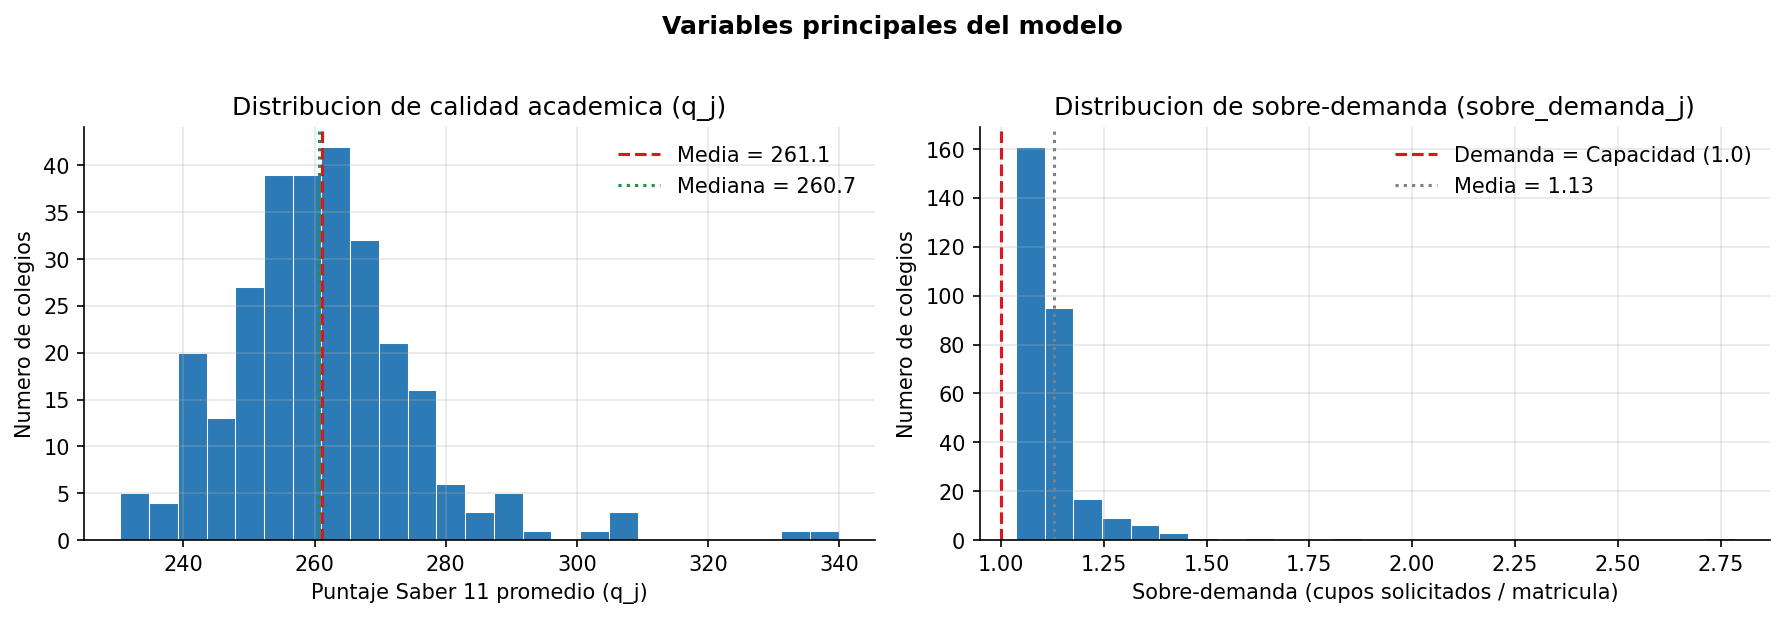

Colegios con sobre_demanda_j > 1: 295 / 295
Colegios con sobre_demanda_j < 0.5: 0 / 295


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- q_j ---
ax = axes[0]
data_q = df['q_j'].dropna()
ax.hist(data_q, bins=25, color=ACCENT, edgecolor='white', linewidth=0.5)
ax.axvline(data_q.mean(), color=RED, linestyle='--', linewidth=1.5, label=f'Media = {data_q.mean():.1f}')
ax.axvline(data_q.median(), color=GREEN, linestyle=':', linewidth=1.5, label=f'Mediana = {data_q.median():.1f}')
ax.set_xlabel('Puntaje Saber 11 promedio (q_j)')
ax.set_ylabel('Numero de colegios')
ax.set_title('Distribucion de calidad academica (q_j)')
ax.legend(frameon=False)

# --- sobre_demanda_j ---
ax = axes[1]
data_sd = df['sobre_demanda_j'].dropna()
ax.hist(data_sd, bins=25, color=ACCENT, edgecolor='white', linewidth=0.5)
ax.axvline(1.0, color=RED, linestyle='--', linewidth=1.5, label='Demanda = Capacidad (1.0)')
ax.axvline(data_sd.mean(), color='gray', linestyle=':', linewidth=1.5, label=f'Media = {data_sd.mean():.2f}')
ax.set_xlabel('Sobre-demanda (cupos solicitados / matricula)')
ax.set_ylabel('Numero de colegios')
ax.set_title('Distribucion de sobre-demanda (sobre_demanda_j)')
ax.legend(frameon=False)

plt.suptitle('Variables principales del modelo', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / '01_distribuciones_principales.png', bbox_inches='tight')
plt.show()
print(f'Colegios con sobre_demanda_j > 1: {(data_sd > 1).sum()} / {len(data_sd)}')
print(f'Colegios con sobre_demanda_j < 0.5: {(data_sd < 0.5).sum()} / {len(data_sd)}')

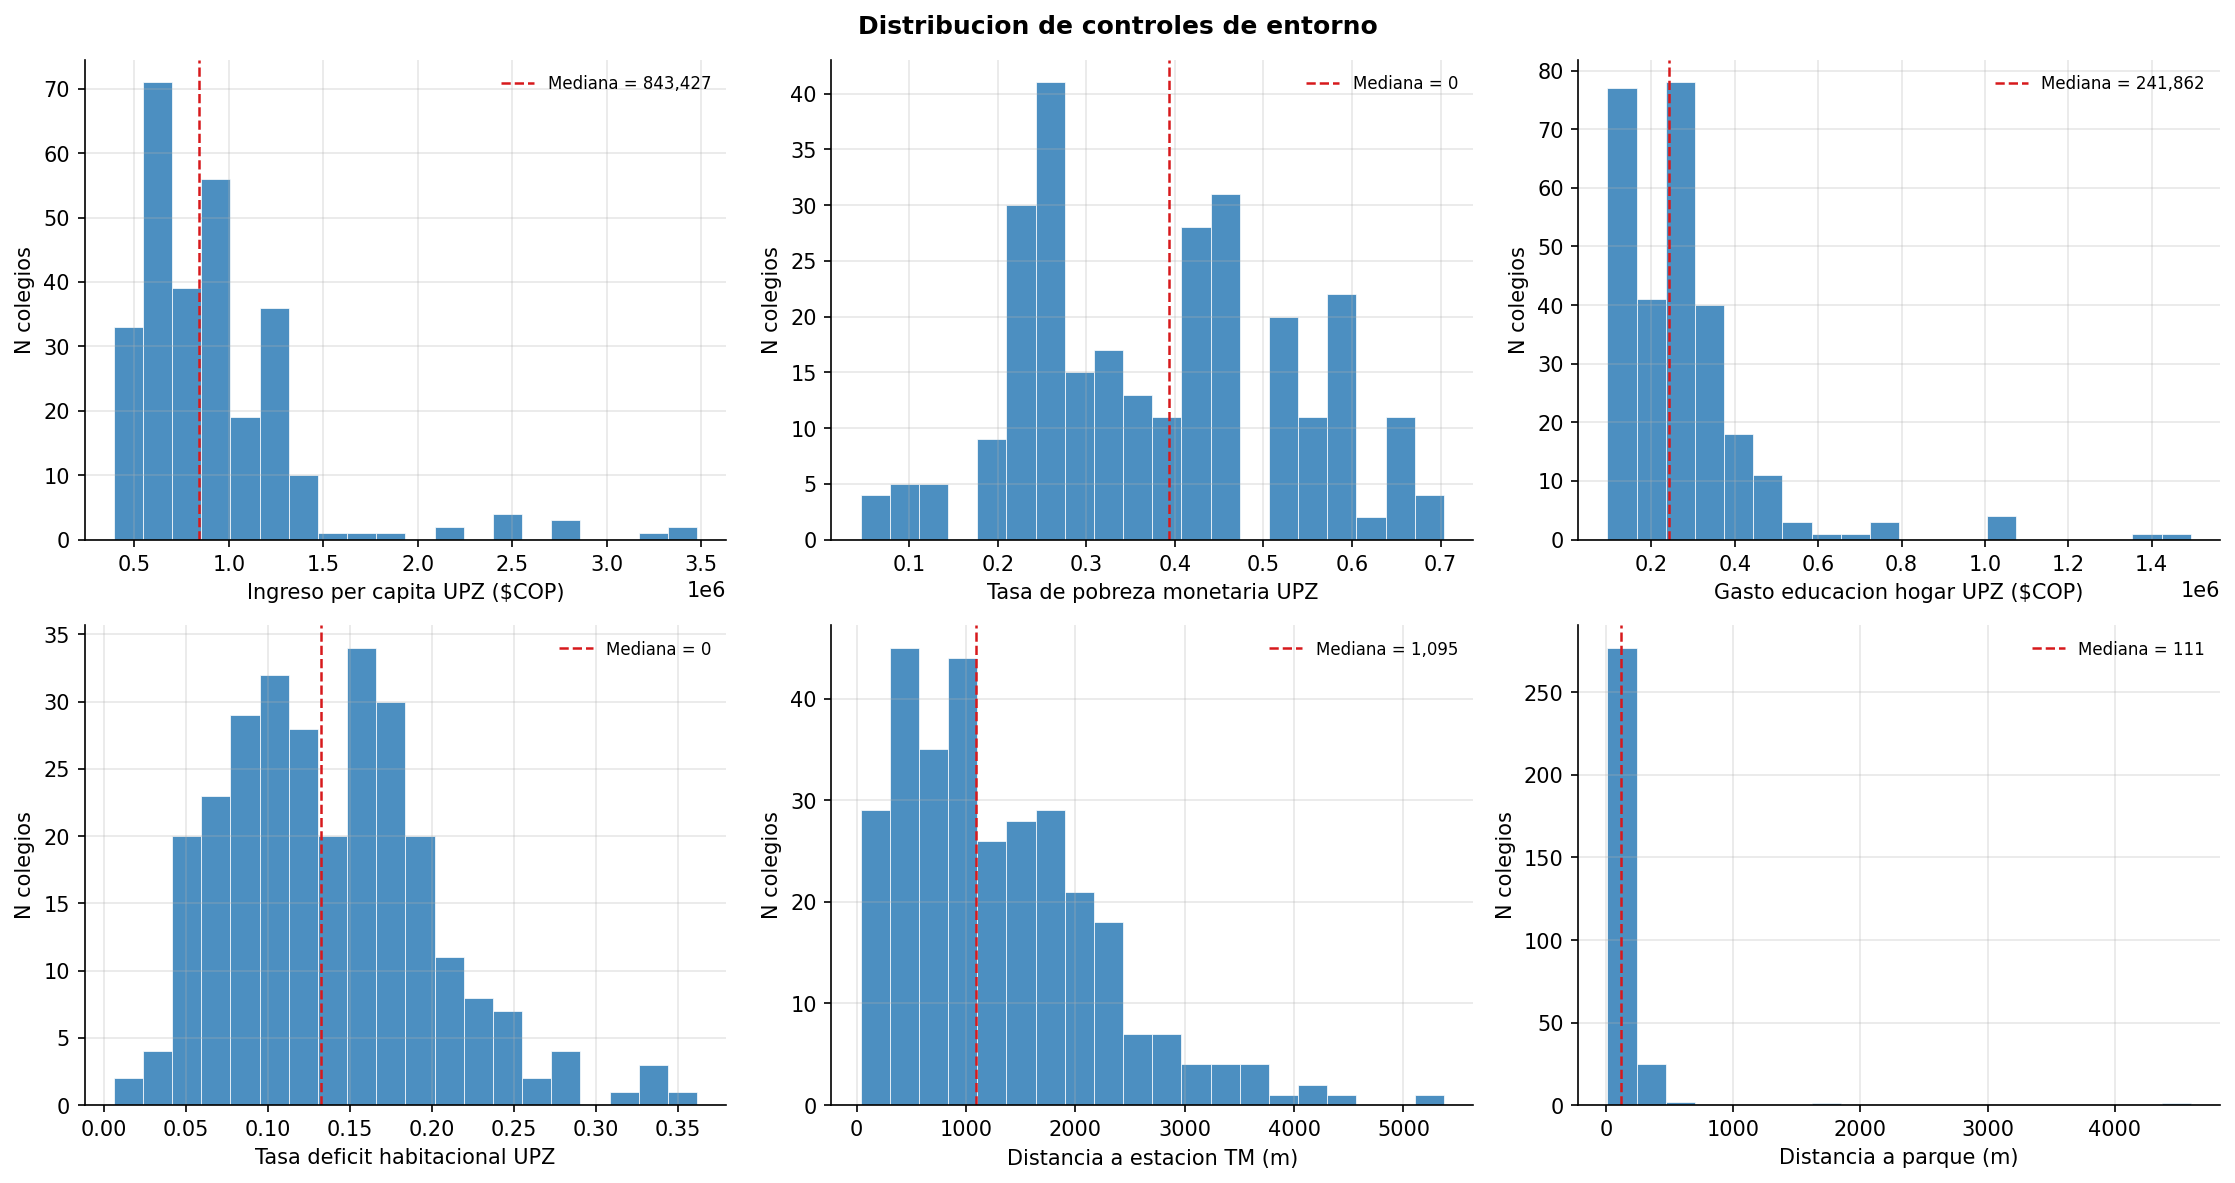

In [6]:
# Distribucion de controles de entorno
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

CONTROL_VARS = [
    ('ingreso_percapita_promedio', 'Ingreso per capita UPZ ($COP)'),
    ('tasa_pobreza_monetaria',     'Tasa de pobreza monetaria UPZ'),
    ('gasto_educ_promedio',        'Gasto educacion hogar UPZ ($COP)'),
    ('tasa_deficit_habitacional',  'Tasa deficit habitacional UPZ'),
    ('dist_transmilenio_m',        'Distancia a estacion TM (m)'),
    ('dist_parque_m',              'Distancia a parque (m)'),
]

for ax, (col, label) in zip(axes, CONTROL_VARS):
    data = df[col].dropna()
    if len(data) == 0:
        ax.set_visible(False)
        continue
    ax.hist(data, bins=20, color=ACCENT, edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline(data.median(), color=RED, linestyle='--', linewidth=1.2,
               label=f'Mediana = {data.median():,.0f}')
    ax.set_xlabel(label)
    ax.set_ylabel('N colegios')
    ax.legend(frameon=False, fontsize=8)

plt.suptitle('Distribucion de controles de entorno', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '02_distribuciones_controles.png', bbox_inches='tight')
plt.show()

---
## 3. Geografia: patrones espaciales

Mapeamos `q_j` y `sobre_demanda_j` sobre las coordenadas de los colegios.
Si hay clustering geografico fuerte, los controles de UPZ y localidad son necesarios para identificacion.

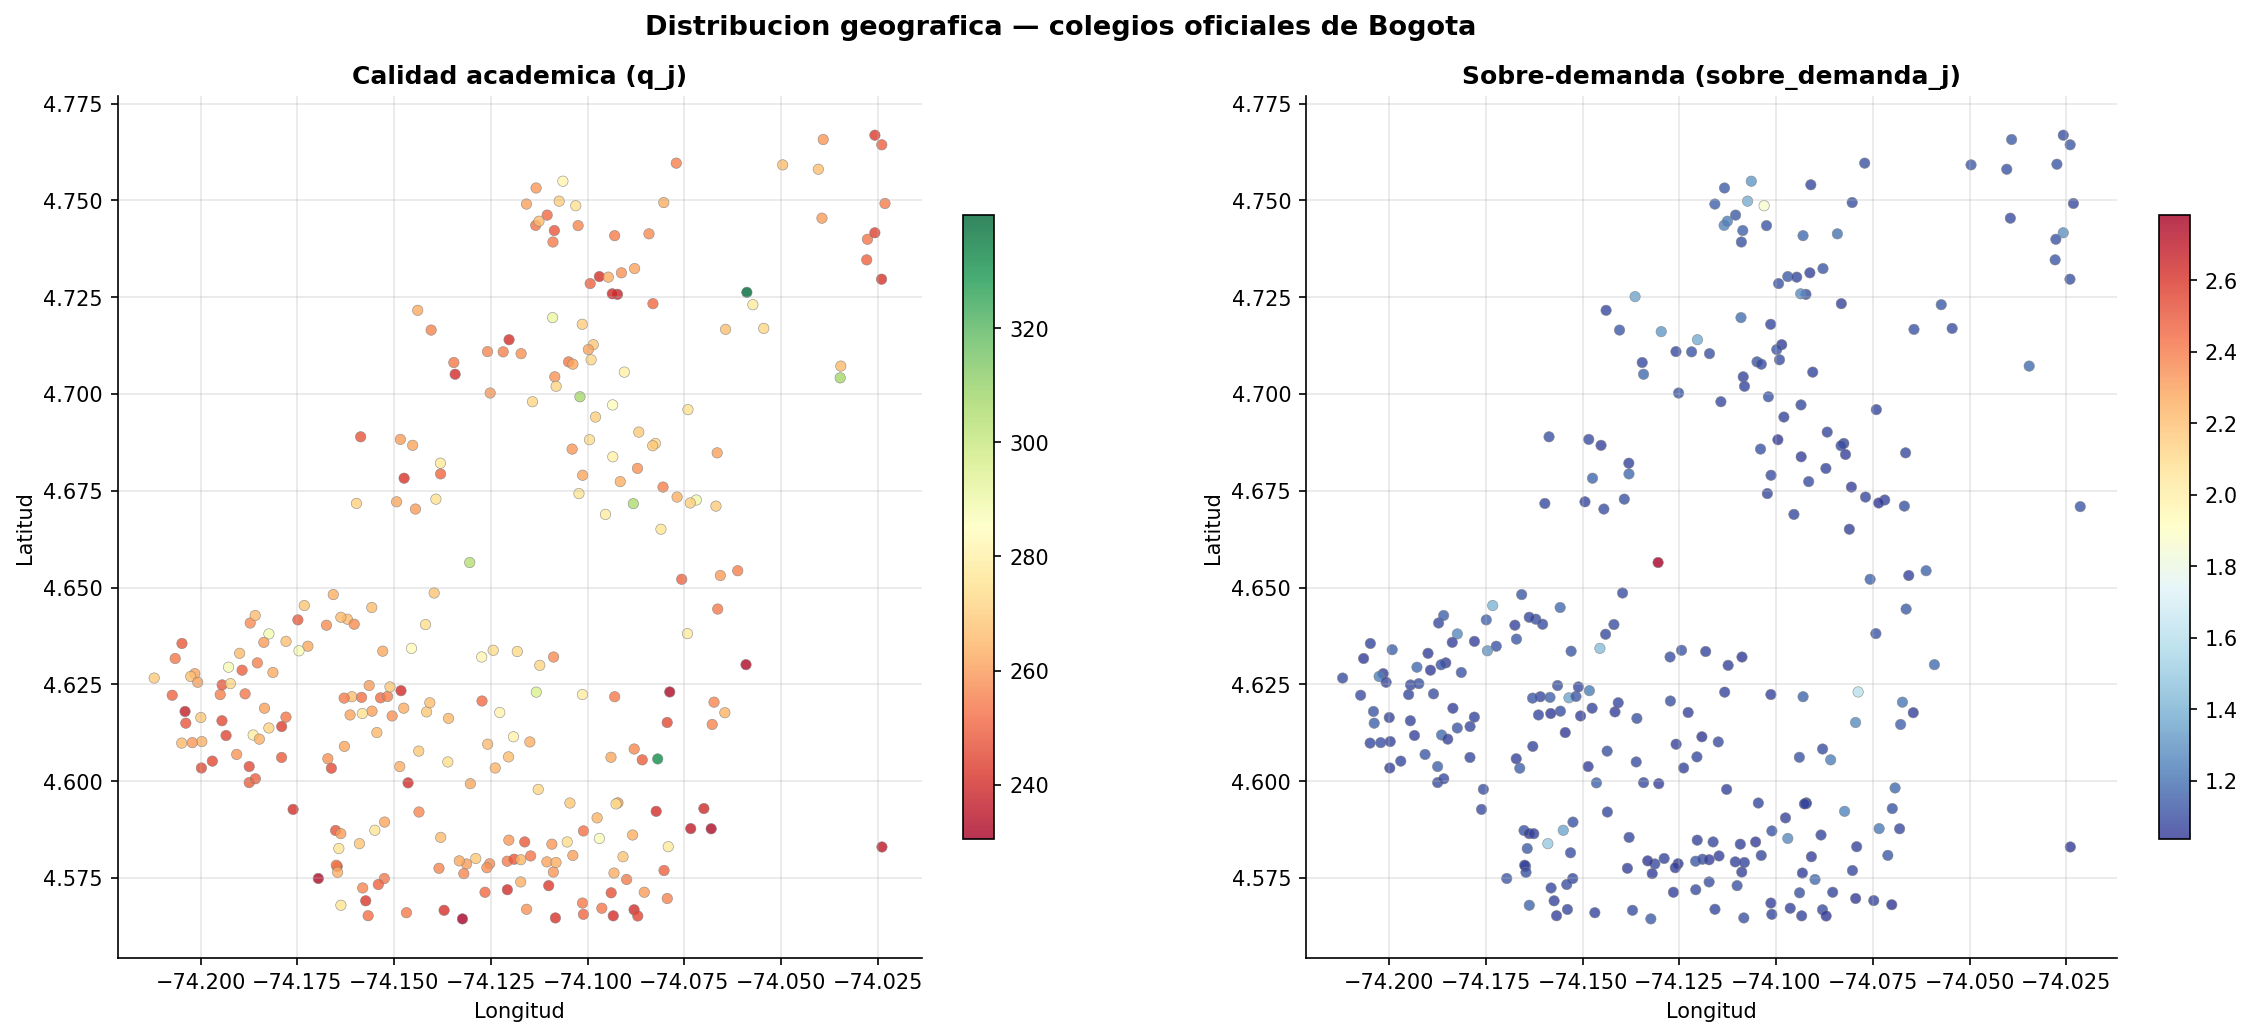

In [7]:
df_geo = df[df['lon'].notna() & df['lat'].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (col, title, cmap) in zip(axes, [
    ('q_j',             'Calidad academica (q_j)',         'RdYlGn'),
    ('sobre_demanda_j', 'Sobre-demanda (sobre_demanda_j)', 'RdYlBu_r'),
]):
    data = df_geo[col]
    valid = df_geo[data.notna()]
    sc = ax.scatter(
        valid['lon'], valid['lat'],
        c=valid[col], cmap=cmap,
        s=25, alpha=0.8, linewidths=0.3, edgecolors='gray'
    )
    plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.set_title(title, fontweight='bold')
    ax.set_aspect('equal')

plt.suptitle('Distribucion geografica — colegios oficiales de Bogota',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '03_mapa_calidad_demanda.png', bbox_inches='tight', dpi=200)
plt.show()

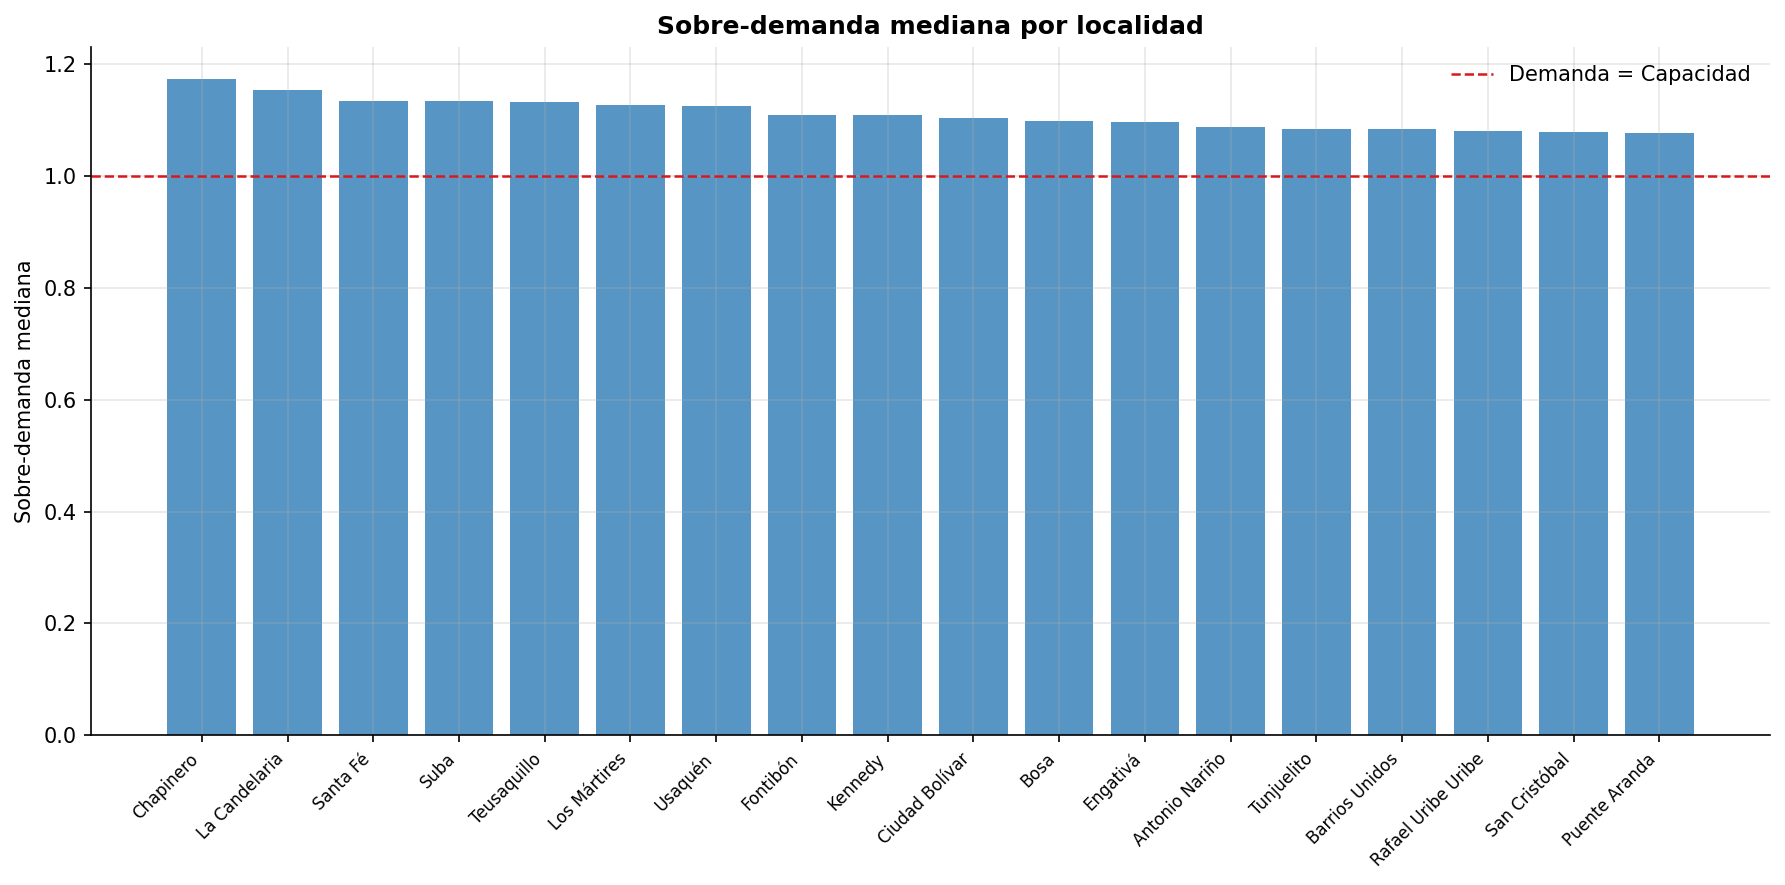

  nombre_localidad  n_colegios  q_j_mediana  sobre_demanda_mediana
         Chapinero           2   243.703333               1.172293
     La Candelaria           1   239.683333               1.152995
          Santa Fé           8   248.503333               1.134196
              Suba          29   259.503333               1.132726
       Teusaquillo           2   266.391667               1.132118
      Los Mártires           8   258.873333               1.126944
           Usaquén          12   254.355000               1.124136
          Fontibón          11   261.926667               1.108663
           Kennedy          43   263.636667               1.108505
    Ciudad Bolívar          17   254.630000               1.103064
              Bosa          40   258.226667               1.097080
          Engativá          34   266.113333               1.095782
    Antonio Nariño           5   264.973333               1.087926
        Tunjuelito          11   256.940000               1.08

In [8]:
# Distribucion por localidad
if 'nombre_localidad' in df.columns:
    loc = (
        df.groupby('nombre_localidad')
        .agg(
            n_colegios=('q_j', 'count'),
            q_j_mediana=('q_j', 'median'),
            sobre_demanda_mediana=('sobre_demanda_j', 'median')
        )
        .dropna()
        .sort_values('sobre_demanda_mediana', ascending=False)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    x = range(len(loc))
    bars = ax.bar(x, loc['sobre_demanda_mediana'], color=ACCENT, alpha=0.8)
    ax.axhline(1.0, color=RED, linestyle='--', linewidth=1.2, label='Demanda = Capacidad')
    ax.set_xticks(x)
    ax.set_xticklabels(loc['nombre_localidad'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Sobre-demanda mediana')
    ax.set_title('Sobre-demanda mediana por localidad', fontweight='bold')
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.savefig(FIGURES / '04_sobre_demanda_por_localidad.png', bbox_inches='tight')
    plt.show()
    print(loc[['nombre_localidad','n_colegios','q_j_mediana','sobre_demanda_mediana']].to_string(index=False))

---
## 4. Relacion q_j vs sobre_demanda_j

Esta es la relacion central del paper. Si `q_j` explicara perfectamente la demanda,
no habria lugar para senales visuales. Los residuales de esta regresion son
la varianza que `v_j` deberia capturar.

Identificamos dos tipos de outliers clave:
- **Alta demanda, baja calidad**: candidatos a tener sesgo visual positivo
- **Baja demanda, alta calidad**: candidatos a ser subvalorados visualmente

In [9]:
from numpy.polynomial import polynomial as P

df_model = df[['nombre_establecimiento','q_j','sobre_demanda_j','nombre_localidad']].dropna()

# Regresion lineal simple: sobre_demanda ~ q_j
x = df_model['q_j'].values
y = df_model['sobre_demanda_j'].values

# OLS manual para R2
X = np.column_stack([np.ones_like(x), x])
beta = np.linalg.lstsq(X, y, rcond=None)[0]
y_hat = X @ beta
ss_res = np.sum((y - y_hat)**2)
ss_tot = np.sum((y - y.mean())**2)
r2 = 1 - ss_res / ss_tot
residuals = y - y_hat

print(f'Regresion: sobre_demanda_j = {beta[0]:.3f} + {beta[1]:.4f} * q_j')
print(f'R2 = {r2:.3f}  (varianza explicada por calidad academica sola)')
print(f'Varianza residual (inexplicada): {(1-r2)*100:.1f}%')

Regresion: sobre_demanda_j = 0.716 + 0.0016 * q_j
R2 = 0.023  (varianza explicada por calidad academica sola)
Varianza residual (inexplicada): 97.7%


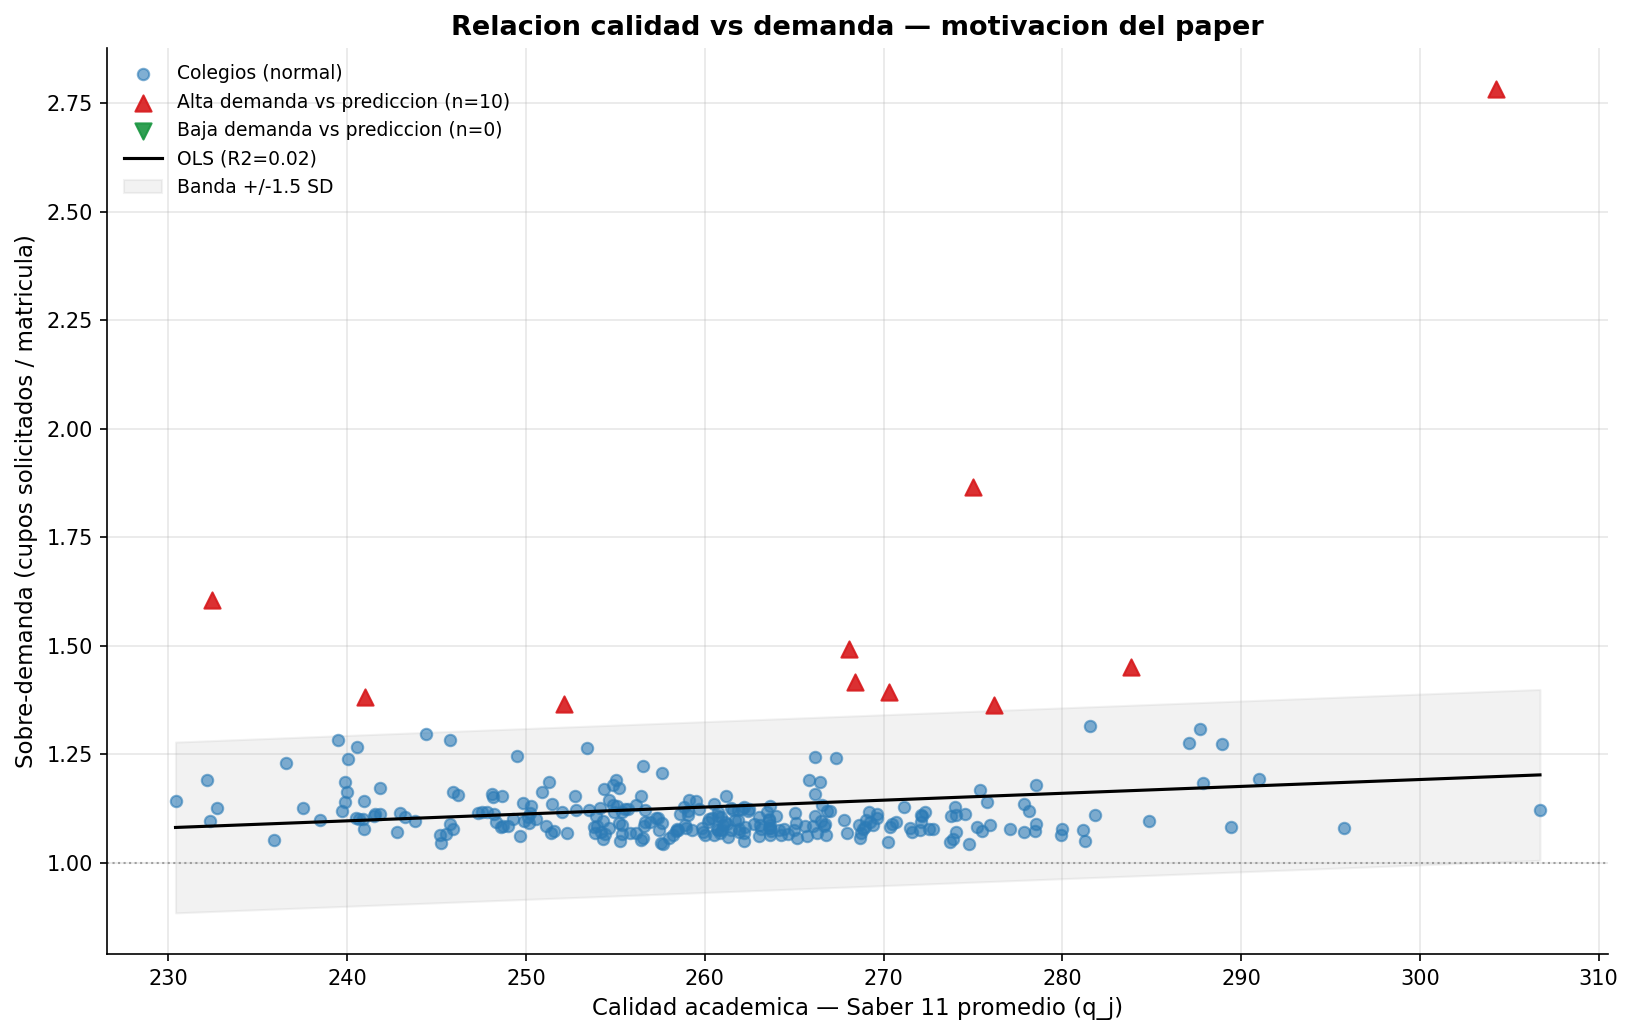

In [10]:
# Umbral para outliers: residual > 1.5 SD
threshold = 1.5 * residuals.std()
df_model = df_model.copy()
df_model['residual'] = residuals
df_model['y_hat'] = y_hat

outlier_high = df_model[df_model['residual'] > threshold]   # alta demanda vs prediccion
outlier_low  = df_model[df_model['residual'] < -threshold]  # baja demanda vs prediccion

fig, ax = plt.subplots(figsize=(11, 7))

# Puntos normales
mask_normal = abs(df_model['residual']) <= threshold
ax.scatter(df_model.loc[mask_normal,'q_j'],
           df_model.loc[mask_normal,'sobre_demanda_j'],
           color=ACCENT, alpha=0.6, s=30, label='Colegios (normal)', zorder=2)

# Outliers alta demanda
ax.scatter(outlier_high['q_j'], outlier_high['sobre_demanda_j'],
           color=RED, alpha=0.9, s=60, marker='^',
           label=f'Alta demanda vs prediccion (n={len(outlier_high)})', zorder=3)

# Outliers baja demanda
ax.scatter(outlier_low['q_j'], outlier_low['sobre_demanda_j'],
           color=GREEN, alpha=0.9, s=60, marker='v',
           label=f'Baja demanda vs prediccion (n={len(outlier_low)})', zorder=3)

# Linea de regresion
x_line = np.linspace(x.min(), x.max(), 100)
y_line = beta[0] + beta[1] * x_line
ax.plot(x_line, y_line, color='black', linewidth=1.5,
        label=f'OLS (R2={r2:.2f})', zorder=4)

# Banda de +/- 1.5 SD
ax.fill_between(x_line, y_line - threshold, y_line + threshold,
                color='gray', alpha=0.1, label='Banda +/-1.5 SD')

ax.axhline(1.0, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.set_xlabel('Calidad academica — Saber 11 promedio (q_j)', fontsize=11)
ax.set_ylabel('Sobre-demanda (cupos solicitados / matricula)', fontsize=11)
ax.set_title('Relacion calidad vs demanda — motivacion del paper', fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / '05_scatter_qj_vs_demanda.png', bbox_inches='tight', dpi=200)
plt.show()

In [11]:
# Tabla de outliers: alta demanda, baja calidad (candidatos a sesgo visual positivo)
print('=== Colegios con demanda mucho MAYOR a lo esperado por su calidad ===')
print('(Posibles candidatos a sesgo visual positivo)\n')
cols_show = ['nombre_establecimiento','nombre_localidad','q_j','sobre_demanda_j','residual']
print(
    outlier_high[cols_show]
    .sort_values('residual', ascending=False)
    .round(2)
    .to_string(index=False)
)

print('\n=== Colegios con demanda mucho MENOR a lo esperado por su calidad ===')
print('(Posibles candidatos a sesgo visual negativo o subutilizacion)\n')
print(
    outlier_low[cols_show]
    .sort_values('residual')
    .round(2)
    .to_string(index=False)
)

=== Colegios con demanda mucho MAYOR a lo esperado por su calidad ===
(Posibles candidatos a sesgo visual positivo)

                         nombre_establecimiento nombre_localidad    q_j  sobre_demanda_j  residual
                     COLEGIO LA FELICIDAD (IED)         Fontibón 304.23             2.78      1.58
COLEGIO FILARMONICO JORGE MARIO BERGOGLIO (IED)             Suba 275.00             1.86      0.71
                     COLEGIO PANAMERICANO (IED)     Los Mártires 232.43             1.60      0.52
                       COLEGIO EL ENSUEÑO (IED)   Ciudad Bolívar 268.08             1.49      0.35
                       COLEGIO EMMA REYES (IED)          Kennedy 283.85             1.45      0.28
                           COLEGIO CHARRY (IED)         Engativá 240.99             1.38      0.28
                       COLEGIO BELLAVISTA (IED)          Kennedy 268.40             1.42      0.27
                         COLEGIO EL JAPON (IED)          Kennedy 252.14             1.37   

---
## 5. Controles socioeconomicos y correlaciones

Evaluamos que controles del EM2021 y geograficos correlacionan con la demanda.
Variables con alta correlacion con `sobre_demanda_j` son candidatas a confounders
que hay que incluir en la regresion de `alpha`.

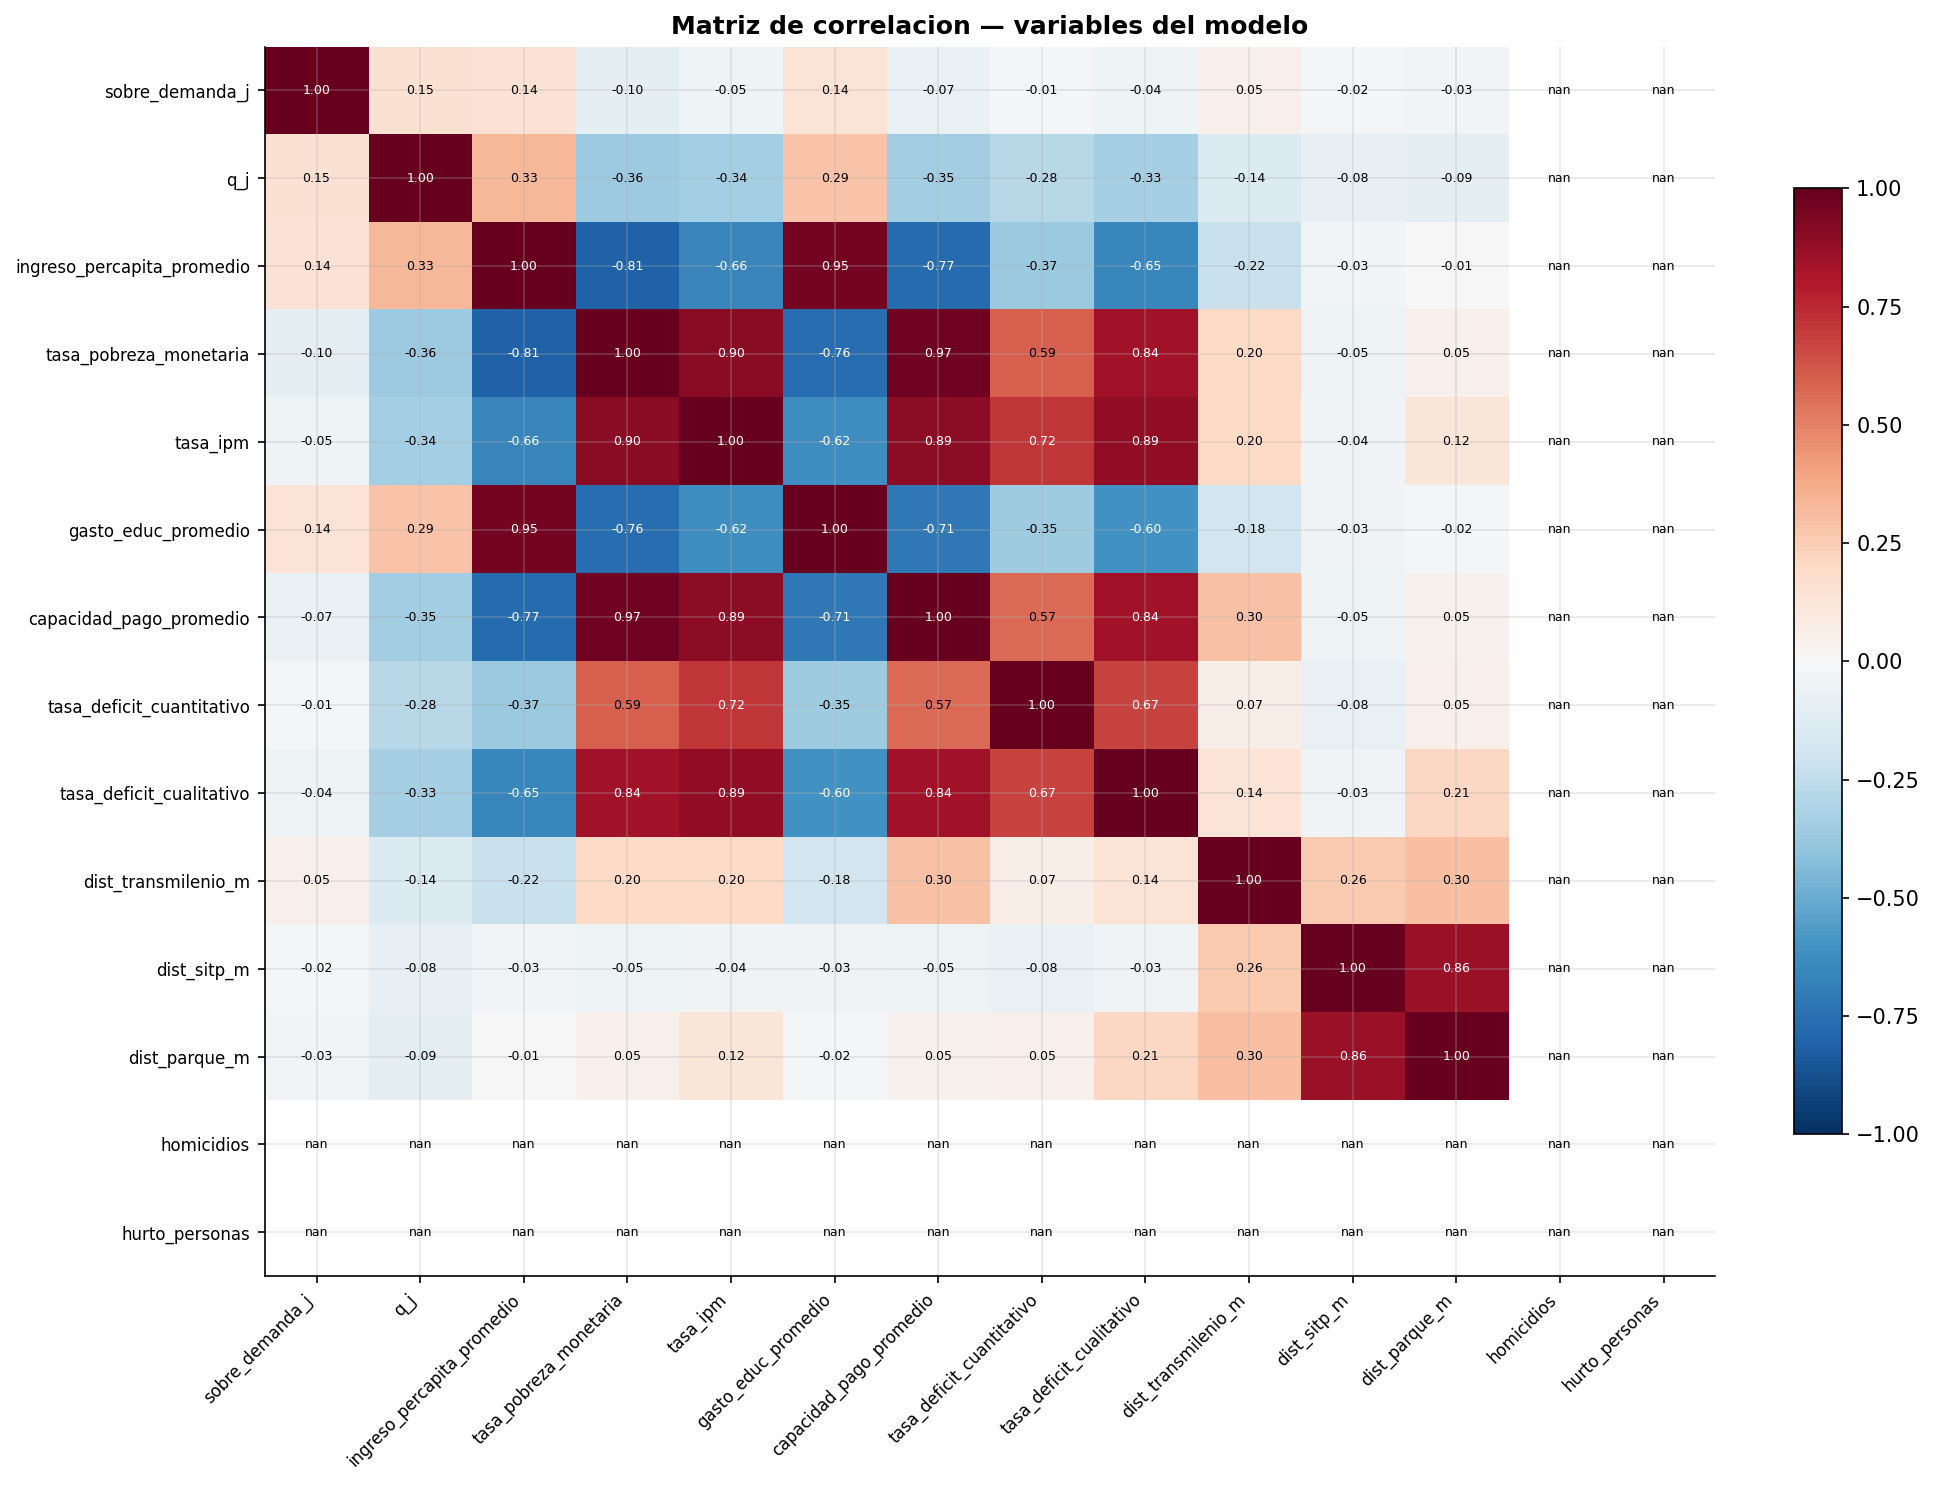

In [12]:
CORR_VARS = [
    'sobre_demanda_j', 'q_j',
    'ingreso_percapita_promedio', 'tasa_pobreza_monetaria', 'tasa_ipm',
    'gasto_educ_promedio', 'capacidad_pago_promedio',
    'tasa_deficit_cuantitativo', 'tasa_deficit_cualitativo',
    'dist_transmilenio_m', 'dist_sitp_m', 'dist_parque_m',
    'homicidios', 'hurto_personas',
]
CORR_VARS = [c for c in CORR_VARS if c in df.columns]

corr_matrix = df[CORR_VARS].corr()

fig, ax = plt.subplots(figsize=(13, 10))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.03)

ax.set_xticks(range(len(CORR_VARS)))
ax.set_yticks(range(len(CORR_VARS)))
ax.set_xticklabels(CORR_VARS, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(CORR_VARS, fontsize=8)

# Anotar valores
for i in range(len(CORR_VARS)):
    for j in range(len(CORR_VARS)):
        val = corr_matrix.values[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=6, color=color)

ax.set_title('Matriz de correlacion — variables del modelo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '06_matriz_correlacion.png', bbox_inches='tight', dpi=200)
plt.show()

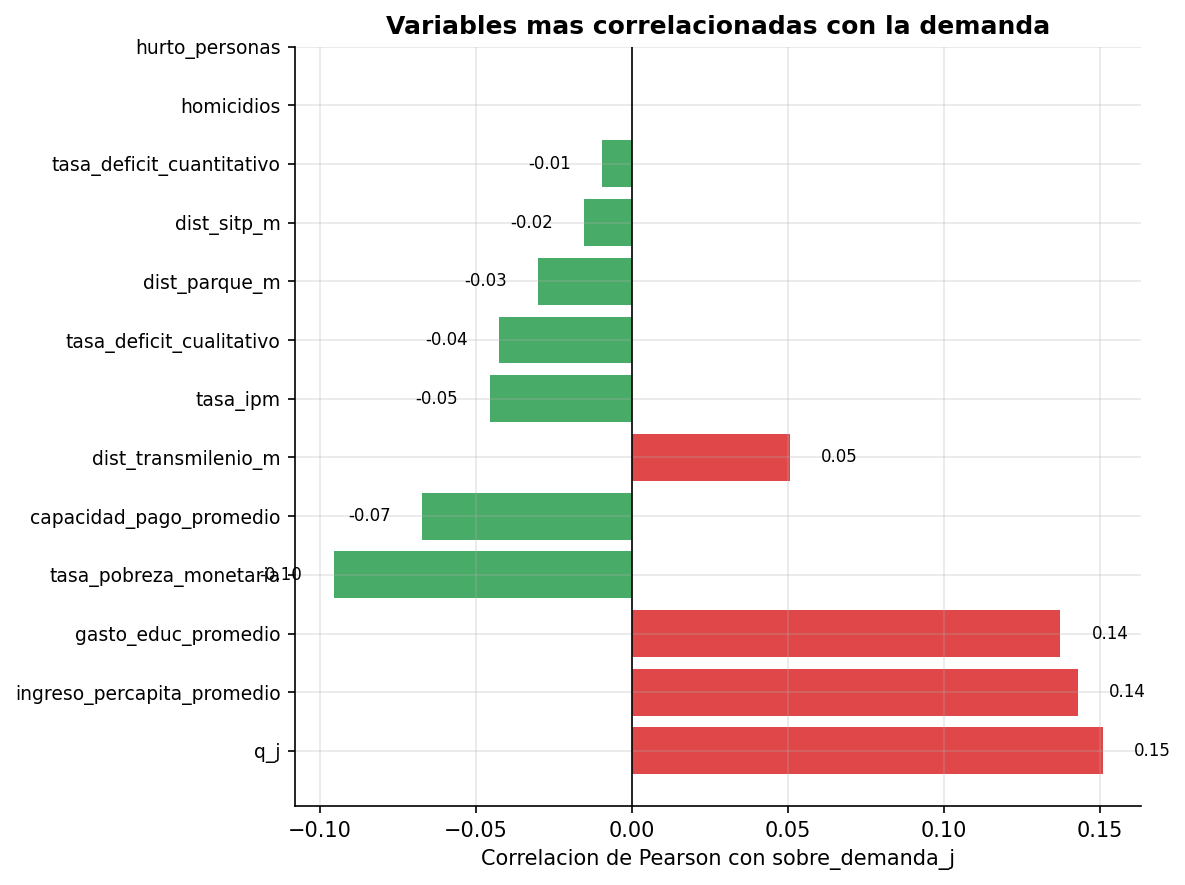

In [13]:
# Correlaciones con sobre_demanda_j ordenadas
corr_sd = corr_matrix['sobre_demanda_j'].drop('sobre_demanda_j').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = [RED if v > 0 else GREEN for v in corr_sd.values]
bars = ax.barh(range(len(corr_sd)), corr_sd.values, color=colors, alpha=0.8)
ax.set_yticks(range(len(corr_sd)))
ax.set_yticklabels(corr_sd.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlacion de Pearson con sobre_demanda_j')
ax.set_title('Variables mas correlacionadas con la demanda', fontweight='bold')

# Anotar valores
for i, v in enumerate(corr_sd.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), i,
            f'{v:.2f}', va='center', ha='left' if v >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES / '07_correlaciones_demanda.png', bbox_inches='tight')
plt.show()

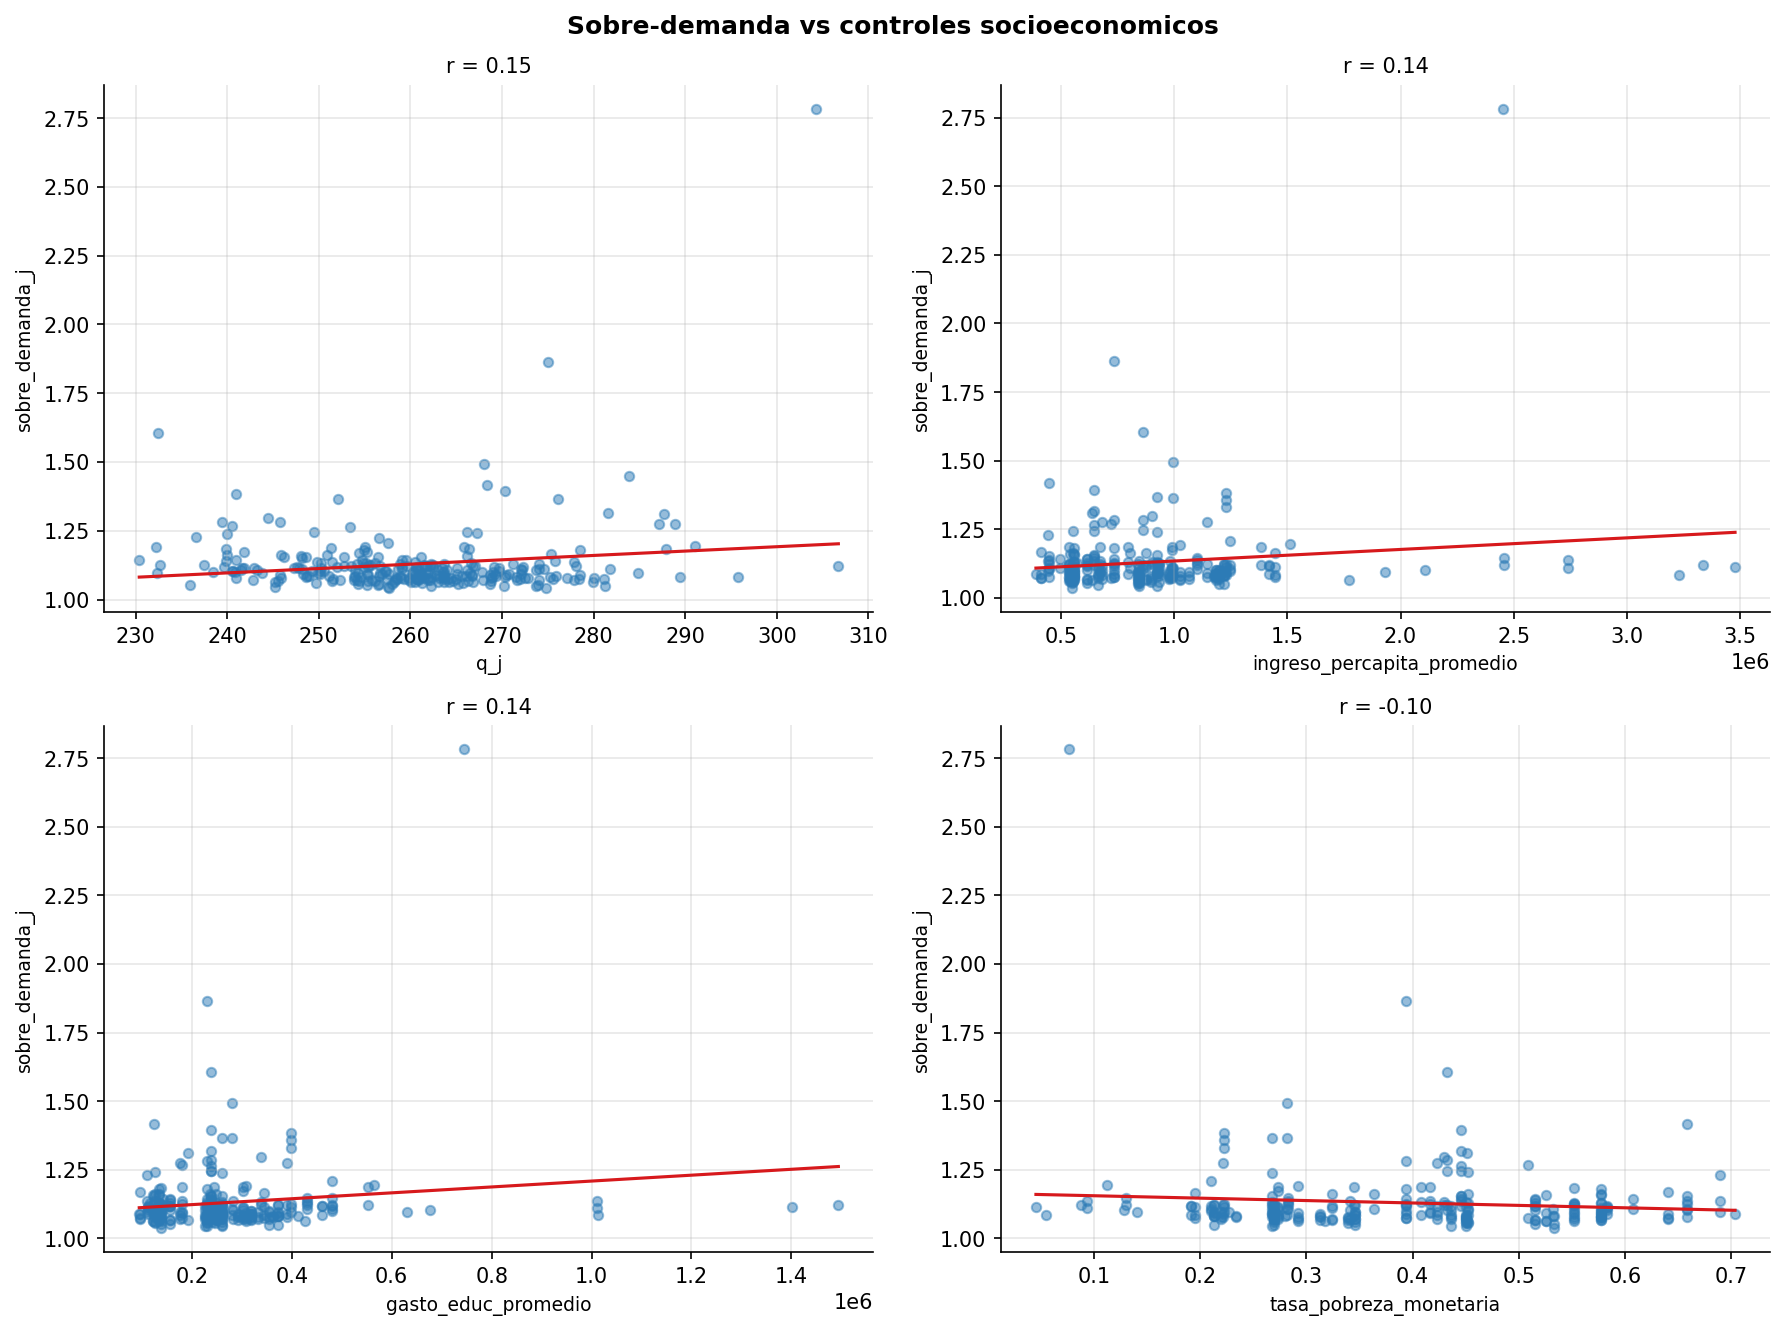

In [14]:
# Scatter sobre_demanda vs controles socioeconomicos mas correlacionados
top_controls = corr_sd.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, col in zip(axes, top_controls):
    data = df[['sobre_demanda_j', col]].dropna()
    ax.scatter(data[col], data['sobre_demanda_j'],
               color=ACCENT, alpha=0.5, s=20)
    # Linea de tendencia
    xv = data[col].values
    yv = data['sobre_demanda_j'].values
    Xm = np.column_stack([np.ones_like(xv), xv])
    b = np.linalg.lstsq(Xm, yv, rcond=None)[0]
    xl = np.linspace(xv.min(), xv.max(), 100)
    ax.plot(xl, b[0] + b[1]*xl, color=RED, linewidth=1.5)
    r = np.corrcoef(xv, yv)[0,1]
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('sobre_demanda_j', fontsize=9)
    ax.set_title(f'r = {r:.2f}', fontsize=10)

plt.suptitle('Sobre-demanda vs controles socioeconomicos', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / '08_scatter_controles.png', bbox_inches='tight')
plt.show()

---
## Resumen del EDA

Resultados clave a reportar en el paper:

In [15]:
print('=' * 60)
print('RESUMEN EDA')
print('=' * 60)
print(f'Colegios en muestra:          {len(df):,}')
print(f'Con q_j (Saber 11):           {df["q_j"].notna().sum():,}')
print(f'Con sobre_demanda_j:          {df["sobre_demanda_j"].notna().sum():,}')
print()
print(f'q_j:   media={df["q_j"].mean():.1f}  SD={df["q_j"].std():.1f}  rango=[{df["q_j"].min():.0f},{df["q_j"].max():.0f}]')
print(f'sobre_demanda_j: media={df["sobre_demanda_j"].mean():.2f}  SD={df["sobre_demanda_j"].std():.2f}')
print(f'Colegios sobre-demandados (>1): {(df["sobre_demanda_j"] > 1).sum()}')
print(f'Colegios sub-demandados (<0.5): {(df["sobre_demanda_j"] < 0.5).sum()}')
print()
print(f'R2 (q_j -> sobre_demanda_j):   {r2:.3f}')
print(f'Varianza INEXPLICADA:           {(1-r2)*100:.1f}%')
print()
print(f'Outliers alta demanda (>{threshold:.2f} SD residual): {len(outlier_high)}')
print(f'Outliers baja demanda (<-{threshold:.2f} SD residual): {len(outlier_low)}')
print()
print('Figuras guardadas en reports/figures/eda/')
for fig_path in sorted(FIGURES.glob('*.png')):
    print(f'  {fig_path.name}')

RESUMEN EDA
Colegios en muestra:          306
Con q_j (Saber 11):           279
Con sobre_demanda_j:          295

q_j:   media=261.1  SD=14.6  rango=[230,340]
sobre_demanda_j: media=1.13  SD=0.13
Colegios sobre-demandados (>1): 295
Colegios sub-demandados (<0.5): 0

R2 (q_j -> sobre_demanda_j):   0.023
Varianza INEXPLICADA:           97.7%

Outliers alta demanda (>0.20 SD residual): 10
Outliers baja demanda (<-0.20 SD residual): 0

Figuras guardadas en reports/figures/eda/
  01_distribuciones_principales.png
  02_distribuciones_controles.png
  03_mapa_calidad_demanda.png
  04_sobre_demanda_por_localidad.png
  05_scatter_qj_vs_demanda.png
  06_matriz_correlacion.png
  07_correlaciones_demanda.png
  08_scatter_controles.png
